11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 122ms/step - loss: 0.1834 - val_loss: 0.1179
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 73s 156ms/step - loss: 0.1151 - val_loss: 0.1108
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 66s 140ms/step - loss: 0.1100 - val_loss: 0.1071
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 146ms/step - loss: 0.1069 - val_loss: 0.1048
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 97s 207ms/step - loss: 0.1049 - val_loss: 0.1048
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 180ms/step - loss: 0.1035 - val_loss: 0.1020
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 153ms/step - loss: 0.1024 - val_loss: 0.1009
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 158ms/step - loss: 0.1016 - val_loss: 0.1003
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 158ms/step - loss: 0.1010 - val_loss: 0.0998
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 86s 183ms/step - loss: 0.1003 - val_loss: 0.0992
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


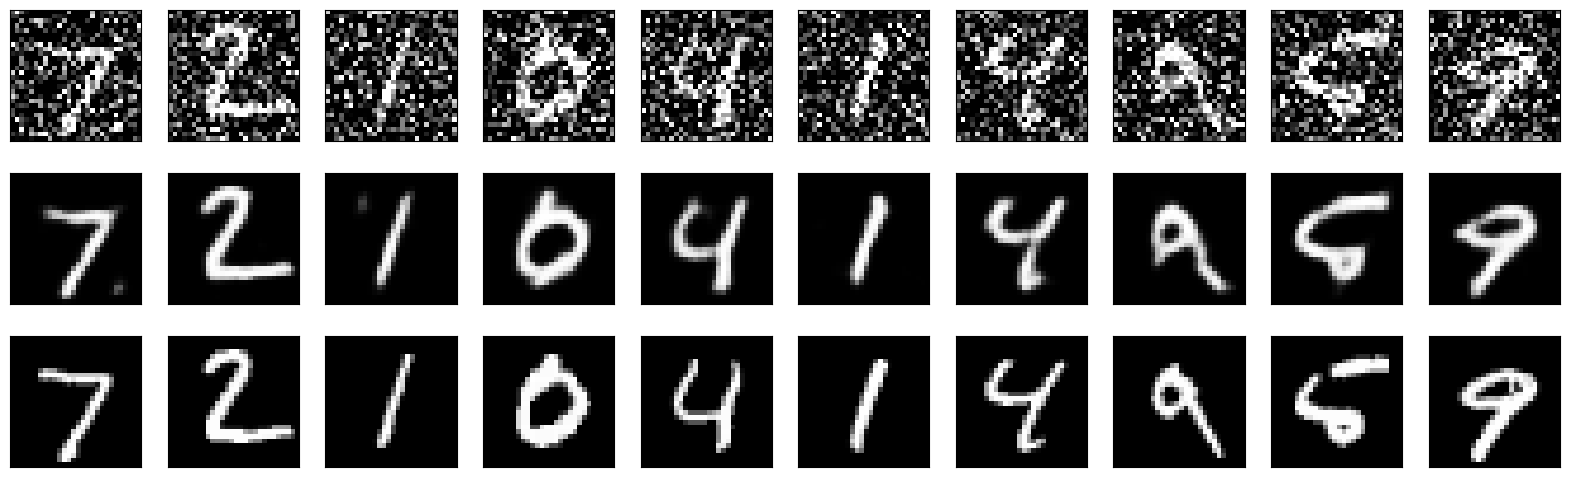

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose
from tensorflow.keras.models import Model

# 1. Load data and normalize to 0-1
(X_train, _), (X_test, _) = tf.keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape for the CNN layers (adding channel dimension)
X_train = np.reshape(X_train, (len(X_train), 28, 28, 1))
X_test = np.reshape(X_test, (len(X_test), 28, 28, 1))

# 2. Add random gaussian noise
noise = 0.5
X_train_noisy = X_train + noise * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

# Clip values so they stay between 0 and 1
X_train_noisy = np.clip(X_train_noisy, 0.0, 1.0)
X_test_noisy = np.clip(X_test_noisy, 0.0, 1.0)

# 3. Model Architecture
input_img = Input(shape=(28, 28, 1))

# Encoder part
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder part
x = Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(encoded)
x = Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Compile model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train using noisy images as input and clean images as targets
history = autoencoder.fit(X_train_noisy, X_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(X_test_noisy, X_test))

# 4. Predict on test set
decoded_imgs = autoencoder.predict(X_test_noisy)

# 5. Plot the results
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Noisy row
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    # Reconstructed row
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    # Original row
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [ ]:
# Results and observations
# Training Performance: The model trained for 10 epochs. The binary_crossentropy loss steadily decreased on both the training set and the validation set, showing that the model was successfully learning without major overfitting.

# How it removes noise: By feeding the network X_train_noisy as the input but using the clean X_train as the target, the autoencoder learns to ignore the random grain. Because the network forces the image through a smaller bottleneck layer, it can't memorize the random noise. Instead, it only learns to pass through the main shapes and features of the actual numbers.

# Visual Results: Looking at the final plotted images, the network did a really good job cleaning up the heavily distorted inputs. The final outputs look much closer to the ground truth rows, though some of the numbers look a little bit blurry around the edges compared to the crisp originals.